In [2]:
import sys, warnings
sys.unraisablehook = lambda u: None
warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive")

In [3]:
import Rbeast as rb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("/home/py/groundwater/")
DATA = ROOT / 'data'
GOWN = DATA / 'gown'

In [4]:
df = pd.read_csv(GOWN / 'combined_absval_20052024_filled.csv', parse_dates=[0], index_col=0)
df = df.sort_index(axis=1)
df_m = df.resample("MS").mean()
df_m.index = df_m.index + pd.Timedelta(days=14)
df_m.columns = df_m.columns.astype(int)

In [5]:
ws = [931, 301, 303, 386, 305, 764, 760, 759, 364]

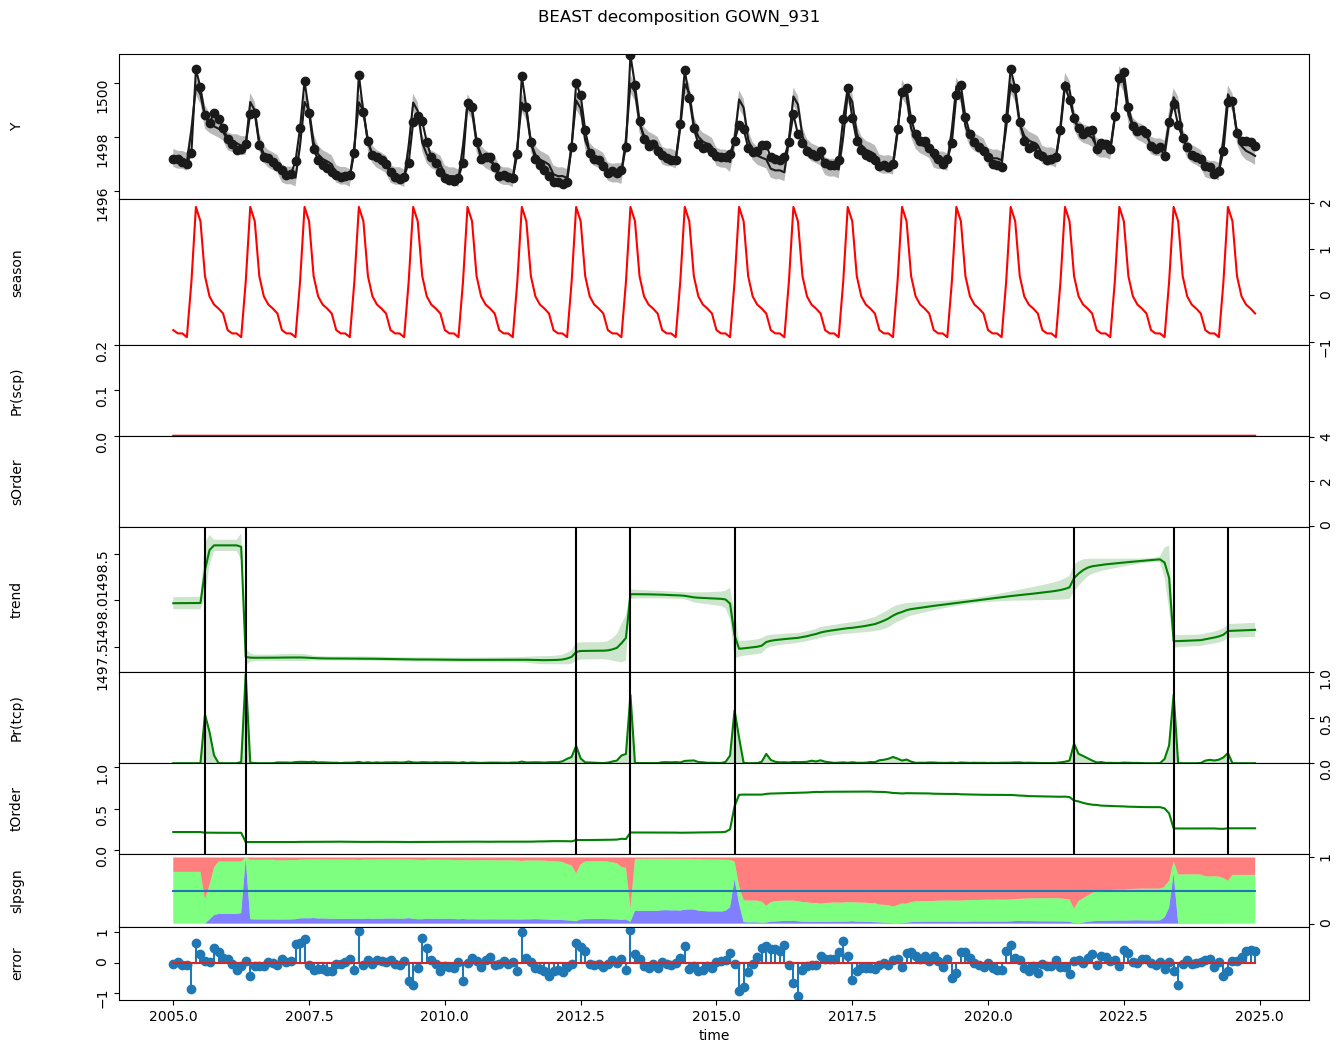

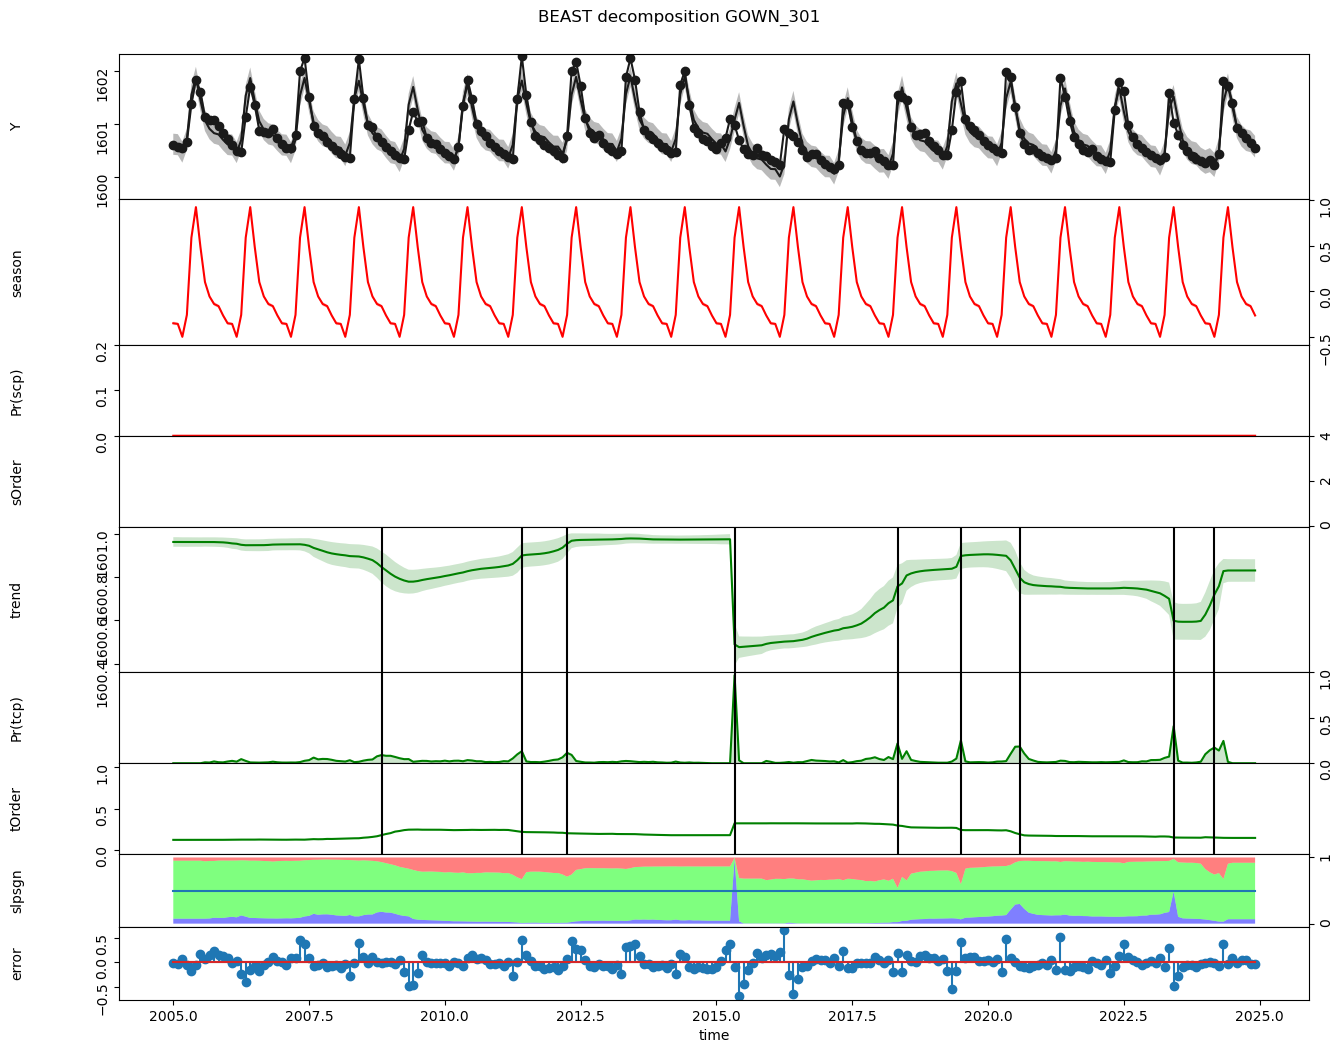

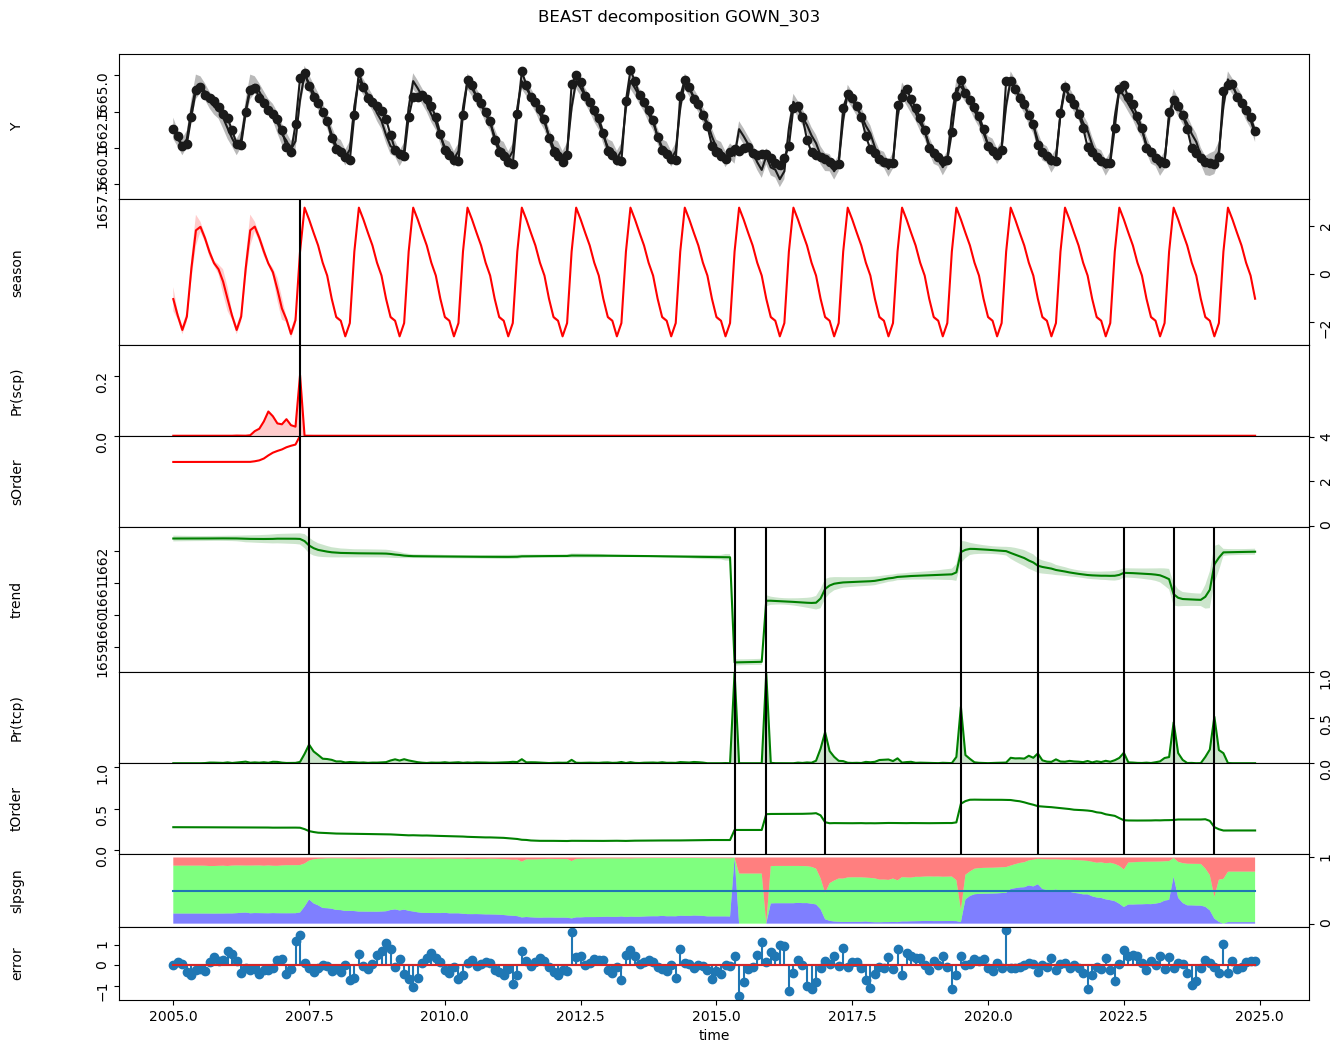

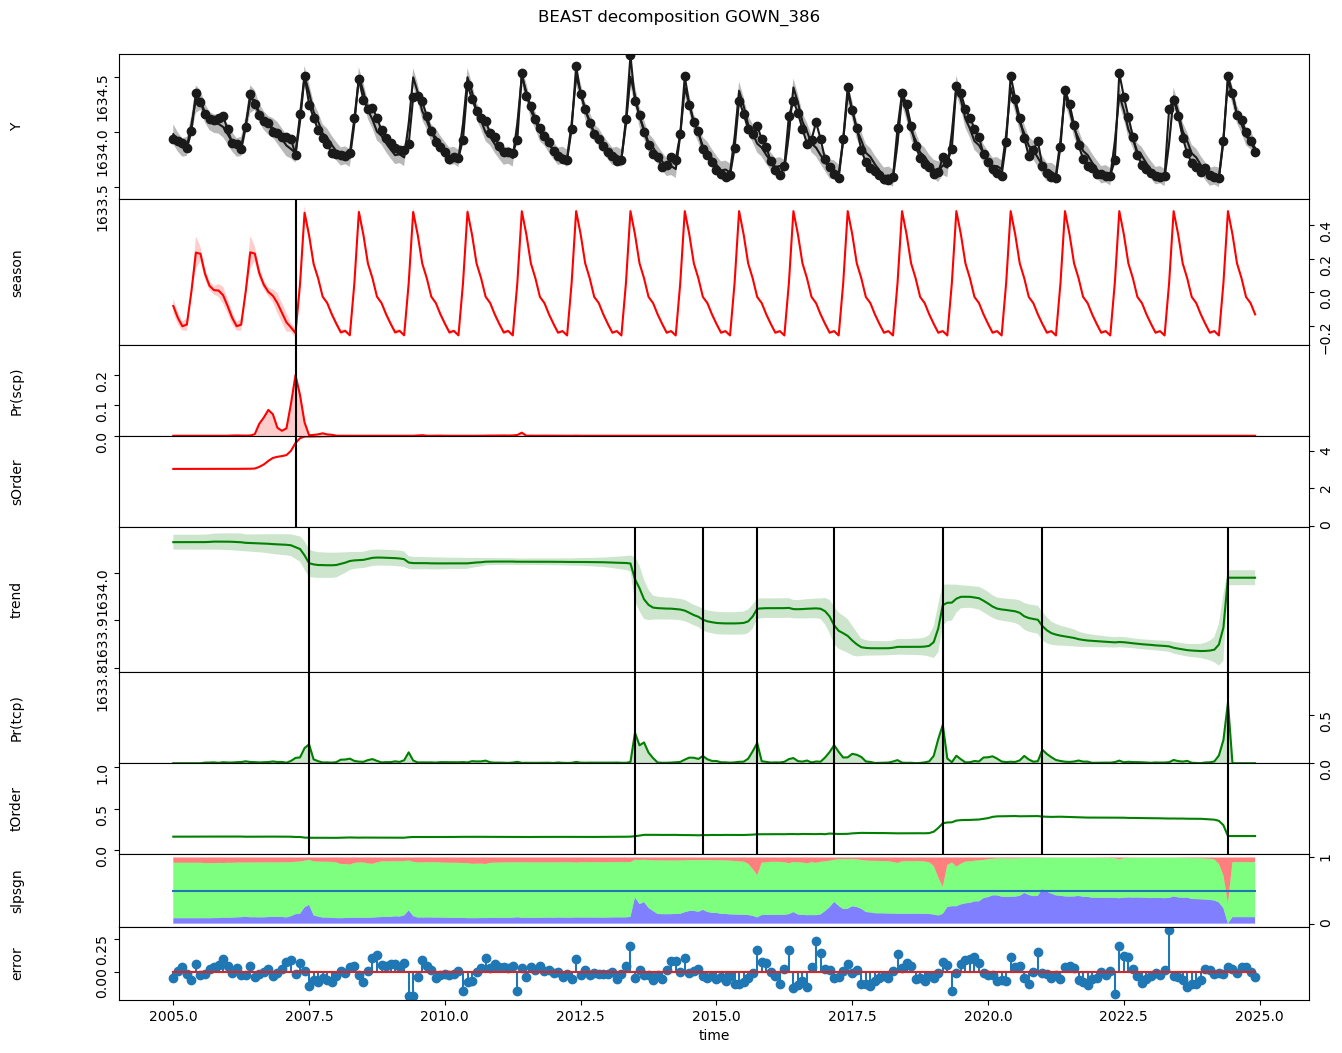

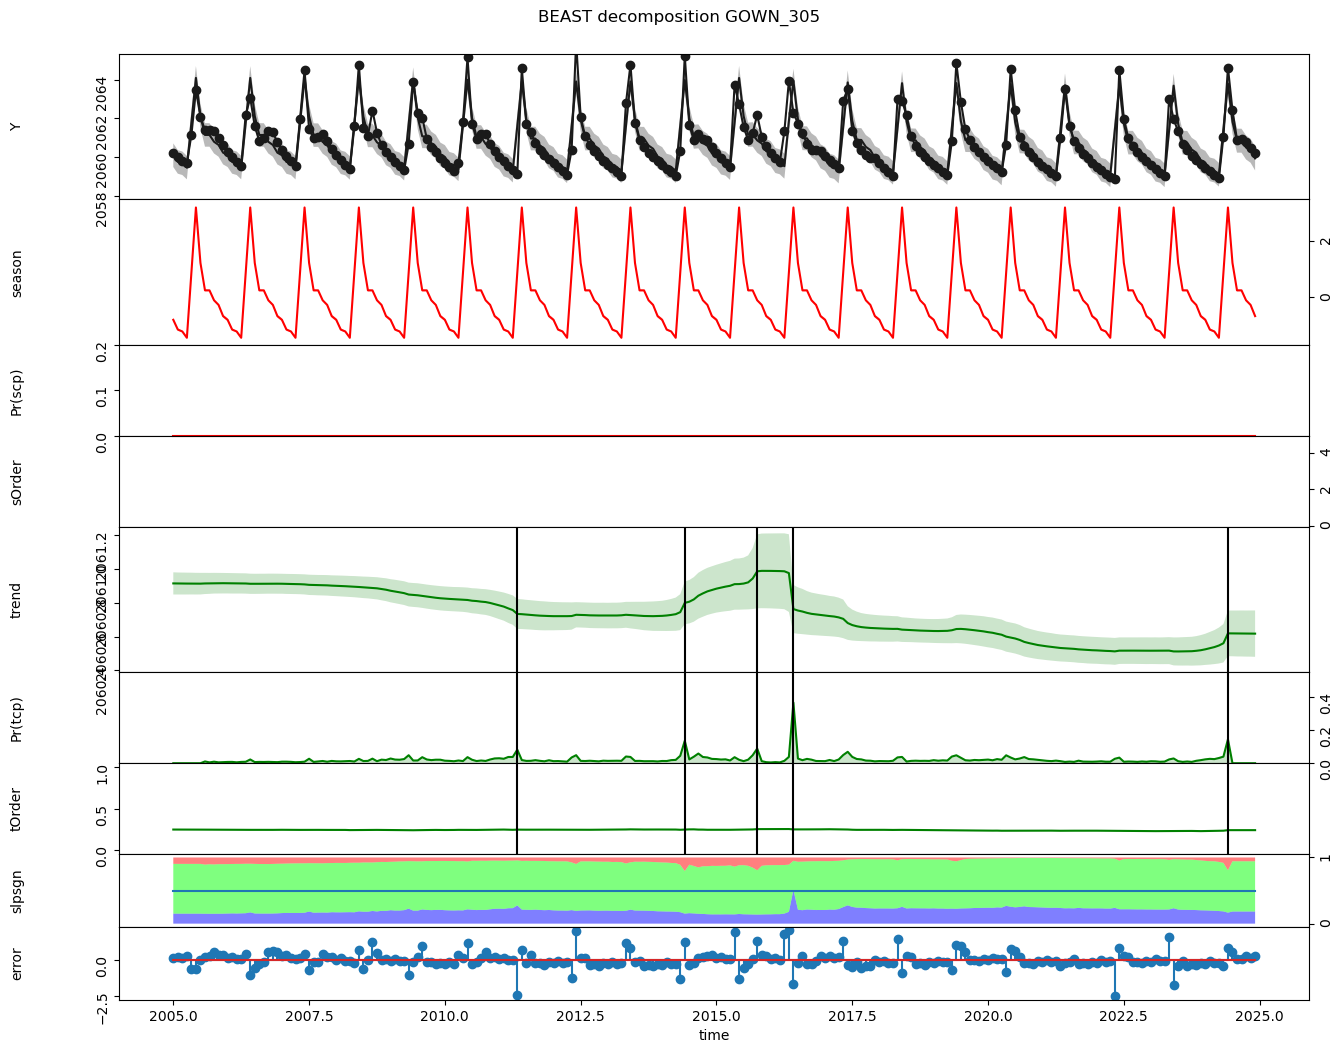

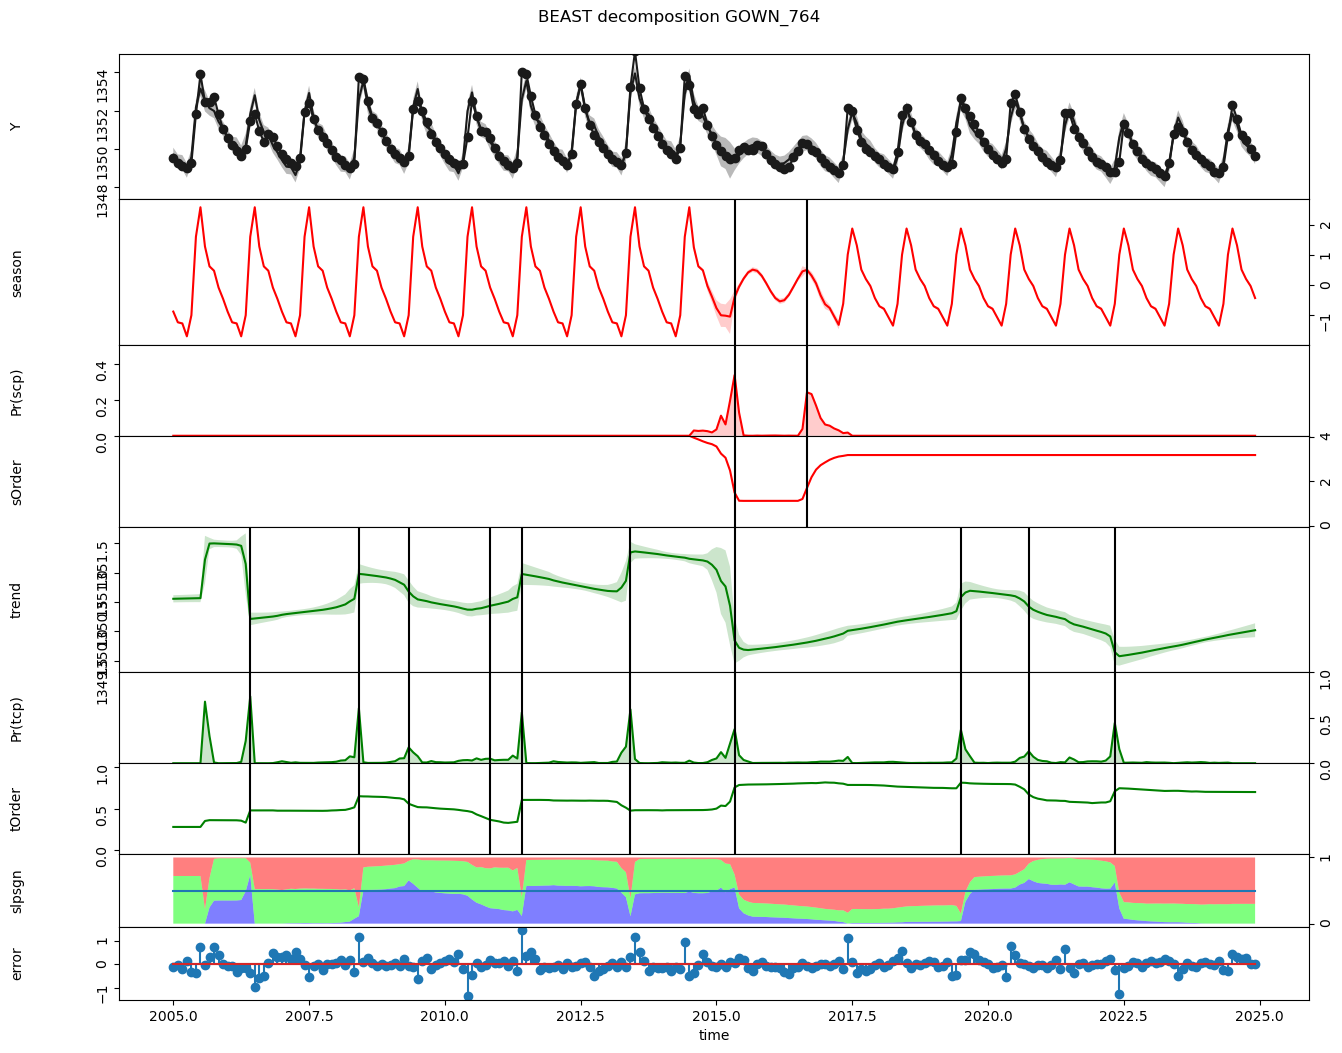

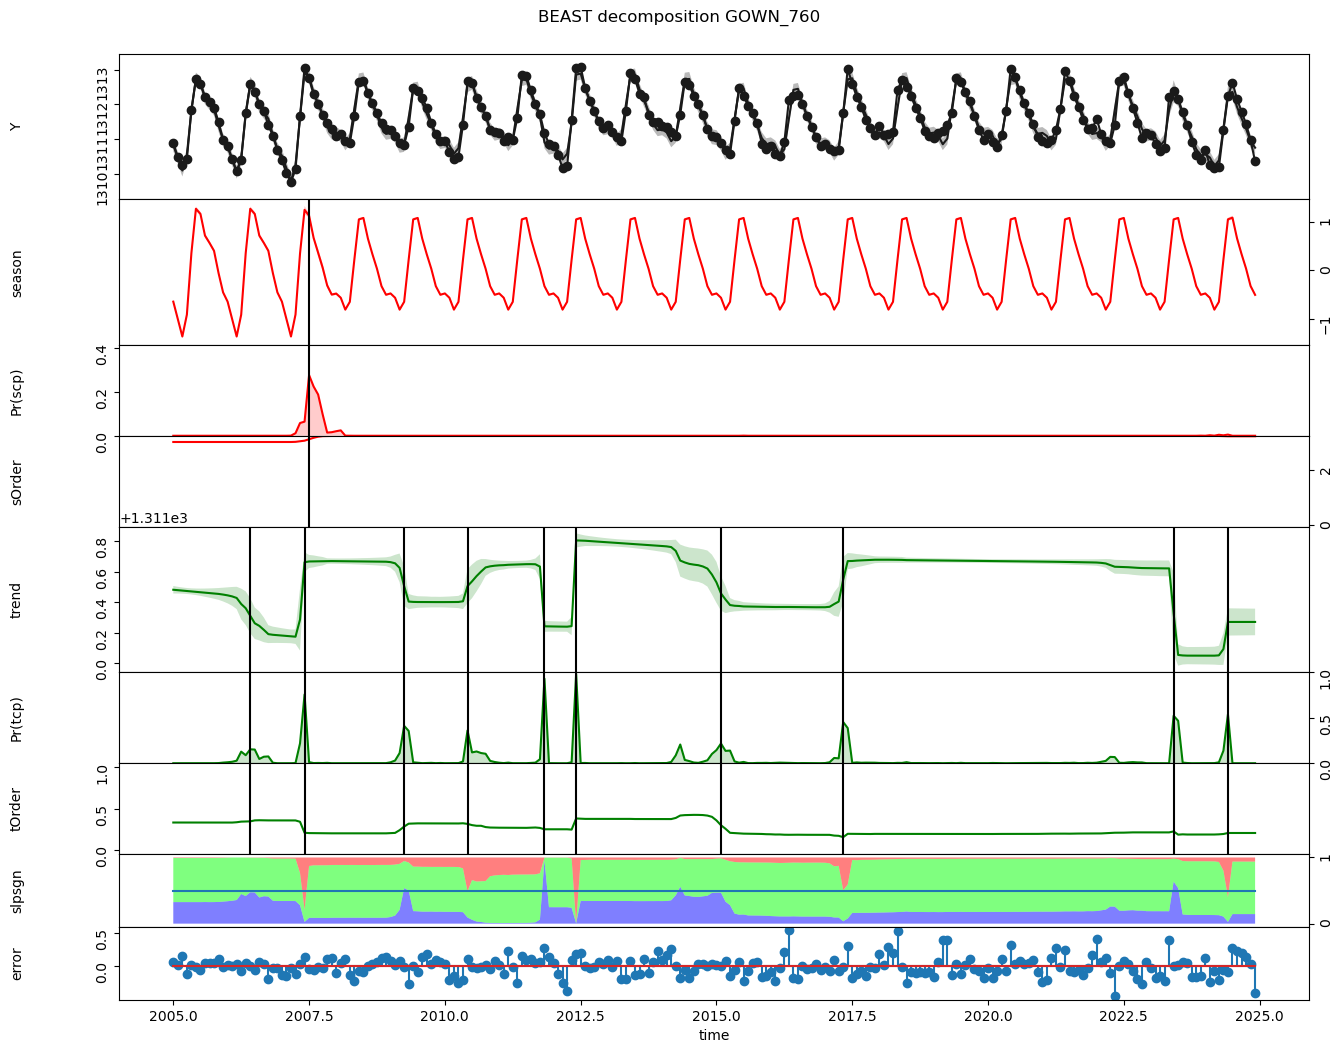

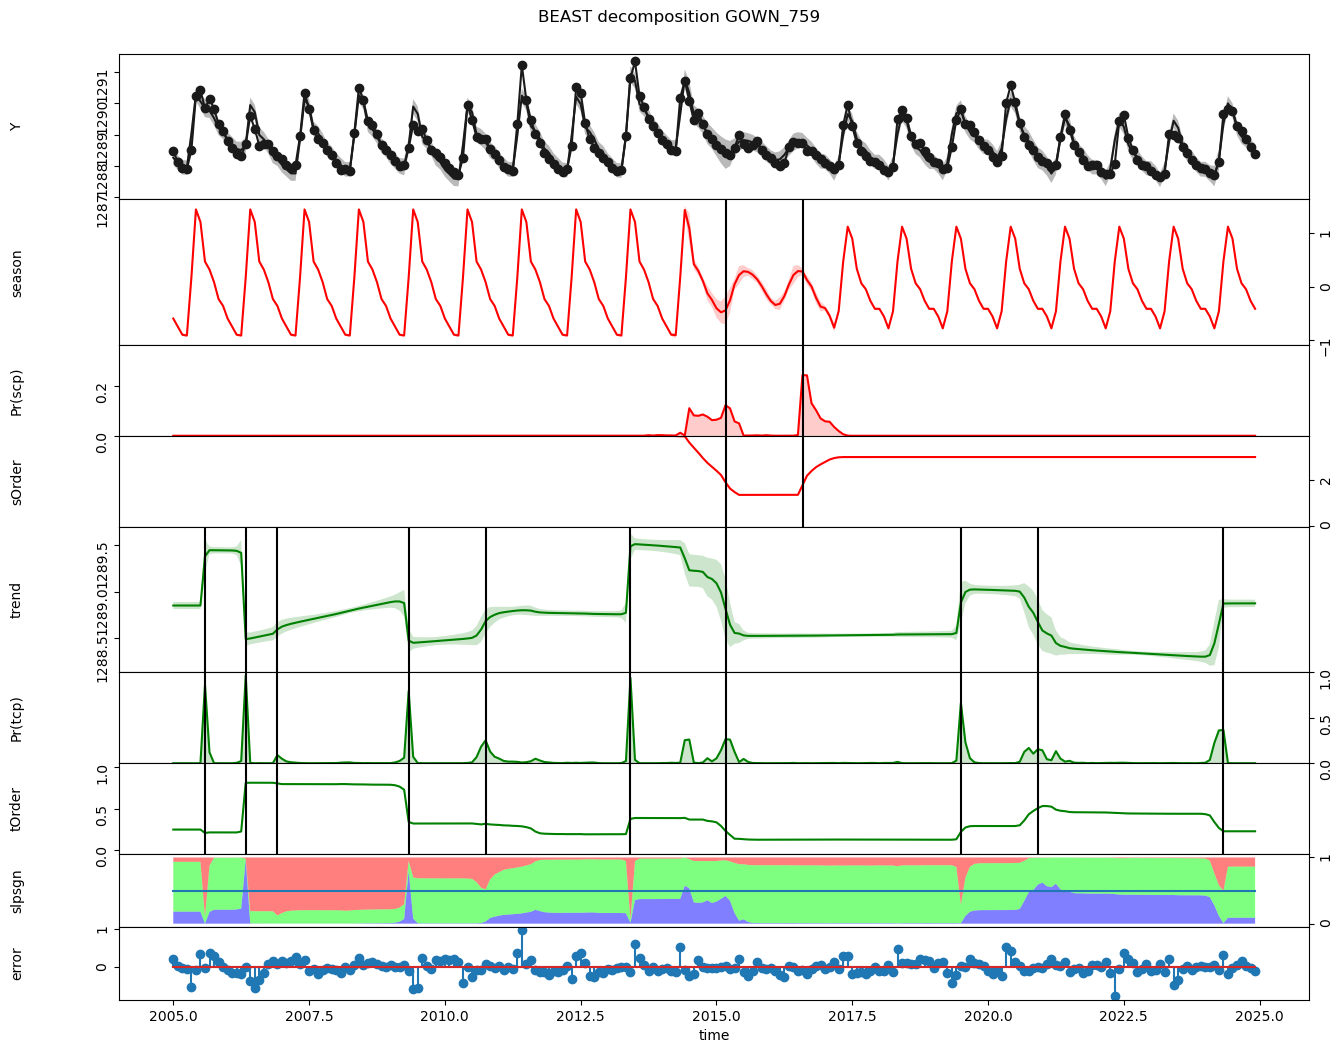

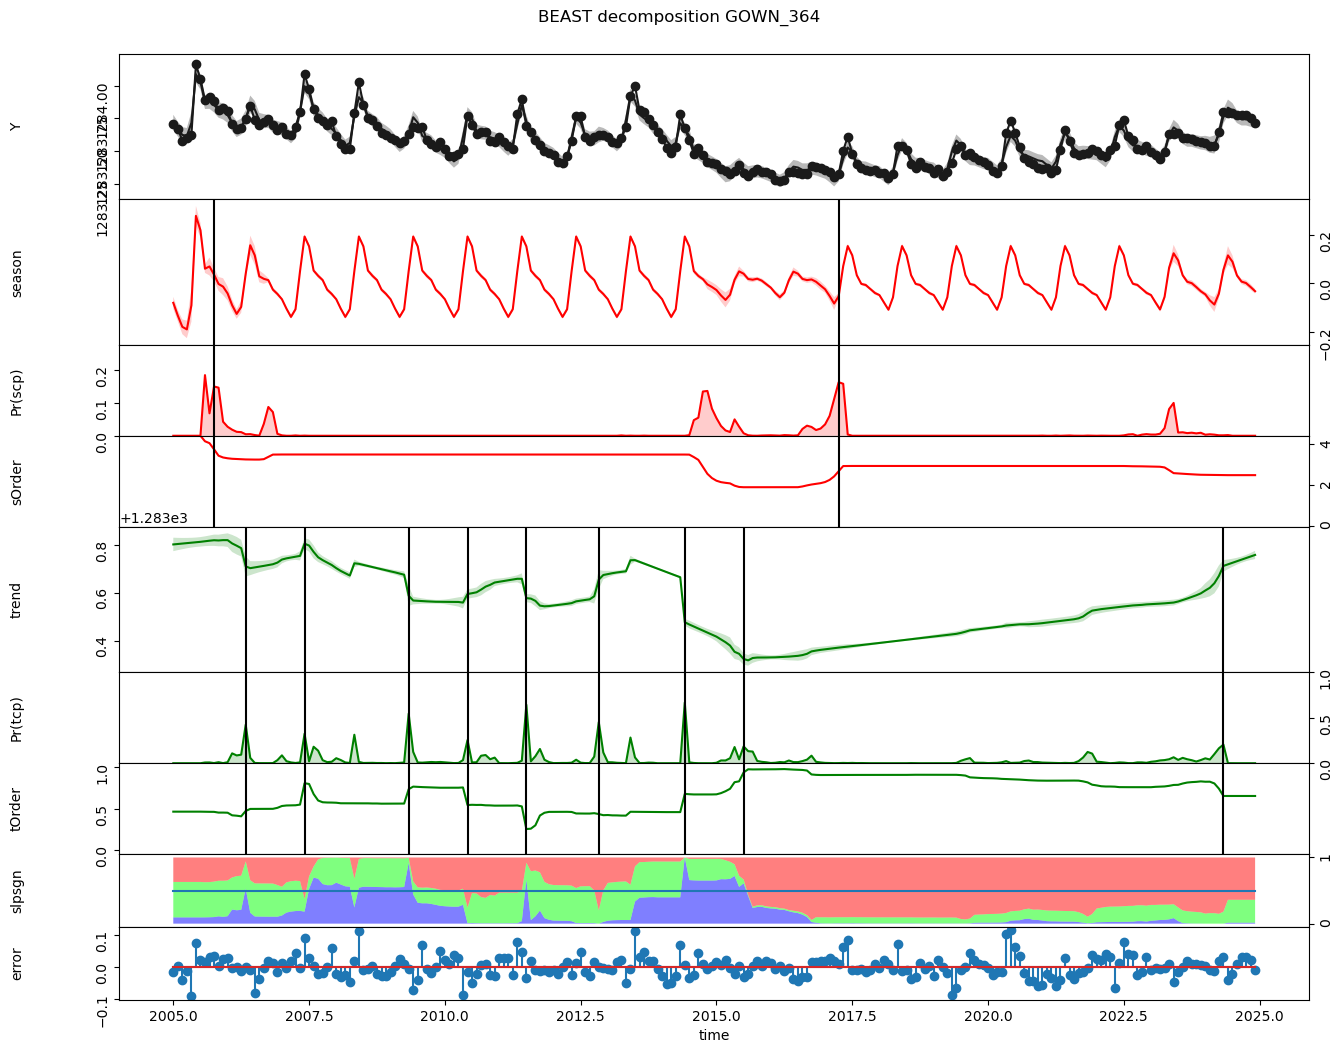

In [6]:
for w in ws:
    y = df_m[w].values

    o = rb.beast(
        y,
        start=[2005, 1, 1],
        deltat="1 month",
        period="1 year",                  # seasonal cycle length
        season="harmonic",                # harmonic seasonal model
        tcp_minmax=[0,10],
        scp_minmax=[0,10],
        print_progress=False, print_options=False, quiet=True,
    )

    rb.plot(o, title=f"BEAST decomposition GOWN_{w}")
    fig = plt.gcf()
    fig.set_size_inches(14, 11)